# 실습 내용

- 데이터 : boston.csv
- 개별 알고리즘으로 모델을 만들어 성능을 확인한다.
- Voting 앙상블을 사용해 모델을 만들어 성능을 확인한다.

# 1.환경 준비

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [42]:
path = './../00_data/boston.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [43]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [45]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


# 3.데이터 전처리

**1) x, y 분리**

In [46]:
target = 'medv'
X = df.drop(target, axis=1)
y = df[target]

**2) 학습용, 평가용 데이터 분리**

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

**3) 정규화**

In [48]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# 4.모델링

## 4.1.Linear Regression 모델링

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *

# 선언하기
model_lr = LinearRegression()

# 학습하기
model_lr.fit(X_train_s, y_train)

# 예측하기
y_pred = model_lr.predict(X_test_s)

# 평가하기
print('MAE:', mean_absolute_error(y_test, y_pred))
print('r2', r2_score(y_test, y_pred))

# # 성능정보 수집
result = {}
result['Linear Regression'] = r2_score(y_test, y_pred)

MAE: 3.4398384295060493
r2 0.772168489913416


## 4.2.KNN 모델링

In [50]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor(n_neighbors=5)

model_knn.fit(X_train_s, y_train)

y_pred = model_knn.predict(X_test_s)

# 평가하기
print("MAE:",mean_absolute_error(y_test, y_pred))
print("R2: ",r2_score(y_test, y_pred))

# 성능정보 수집
result['KNN'] = r2_score(y_test, y_pred)

MAE: 3.287894736842105
R2:  0.7538844474489568


## 4.3.Decision Tree 모델링

In [51]:
# 불러오기
from sklearn.tree import DecisionTreeRegressor

# 선언하기
model_dt = DecisionTreeRegressor(max_depth=5)

# 학습하기
model_dt.fit(X_train, y_train)

# 예측하기
y_pred = model_dt.predict(X_test)

# 평가하기
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

# 성능정보 수집
result['Decision Tree'] = r2_score(y_test, y_pred)

3.1142390594920273
0.7365856382116718


## 4.4.Random Forest 모델링

In [52]:
from sklearn.ensemble import RandomForestRegressor

# 선언하기
model_rdf = RandomForestRegressor()

# 학습하기
model_rdf.fit(X_train, y_train)

# 예측하기
y_pred = model_rdf.predict(X_test)

# 평가하기
print('MAE:', mean_absolute_error(y_test, y_pred))
print('r2', r2_score(y_test, y_pred))

# 성능정보 수집
result['Random Forest'] = r2_score(y_test, y_pred)

MAE: 2.3212894736842107
r2 0.8933496960488396


## 4.5.LightGBM 모델링

In [53]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_lgbm = LGBMRegressor(
    min_child_samples=5,        # 리프 노드 하나에 5개 데이터만 있어도 허용. 하나의 리프 노드에 최소 몇 개의 데이터가 있어야 하는지.
    max_depth=15,               # 트리의 최대 깊이
    min_split_gain=0.0,         # 노드를 한 번 더 나눌 때 최소한 어느 정도 정보 이득이 있어야 하는지 0.0:거의 제한을 두지 않는 설정
    colsample_bytree=1.0, # 각 트리를 만들 때 전체 컬럼 중 몇 %를 사용할 것인지. 0.8: 매 트리마다 8개 컬럼 정도만 랜덤 사용.
    verbose=-1
)

model_lgbm.fit(X_train, y_train)

y_pred = model_lgbm.predict(X_test)

print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

result['LigthGBM'] = r2_score(y_test, y_pred)

2.347963776880968
0.8887890418401695


## 4.6.Voting

- Voting 앙상블을 사용해 모델링하고 성능을 확인한다.

In [54]:
from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import make_pipeline

# 모델 설정하기(사용할 모델들을 지정)
estimators = [('lr', make_pipeline(MinMaxScaler(), LinearRegression())),
              ('dt', DecisionTreeRegressor()),
              ('knn', make_pipeline(MinMaxScaler(), KNeighborsRegressor())),        # 입력 스케일 조정 후 적용
              ('rdf', RandomForestRegressor())]

# 위에서 지정한 여러 모델을 하나로 묶엇서 model_vt 생성
model_vt = VotingRegressor(estimators=estimators)

# 학습하기
model_vt.fit(X_train, y_train)

# 예측하기
y_pred = model_vt.predict(X_test)

# 평가하기
print('MAE:', mean_absolute_error(y_test, y_pred))
print('r2', r2_score(y_test, y_pred))

# 성능정보 수집
result['Voting'] = r2_score(y_test, y_pred)

MAE: 2.455059836119929
r2 0.8839993473379273


# 5.성능 비교

- 위에서 수집한 성능 정보를 시각화해 비교한다.

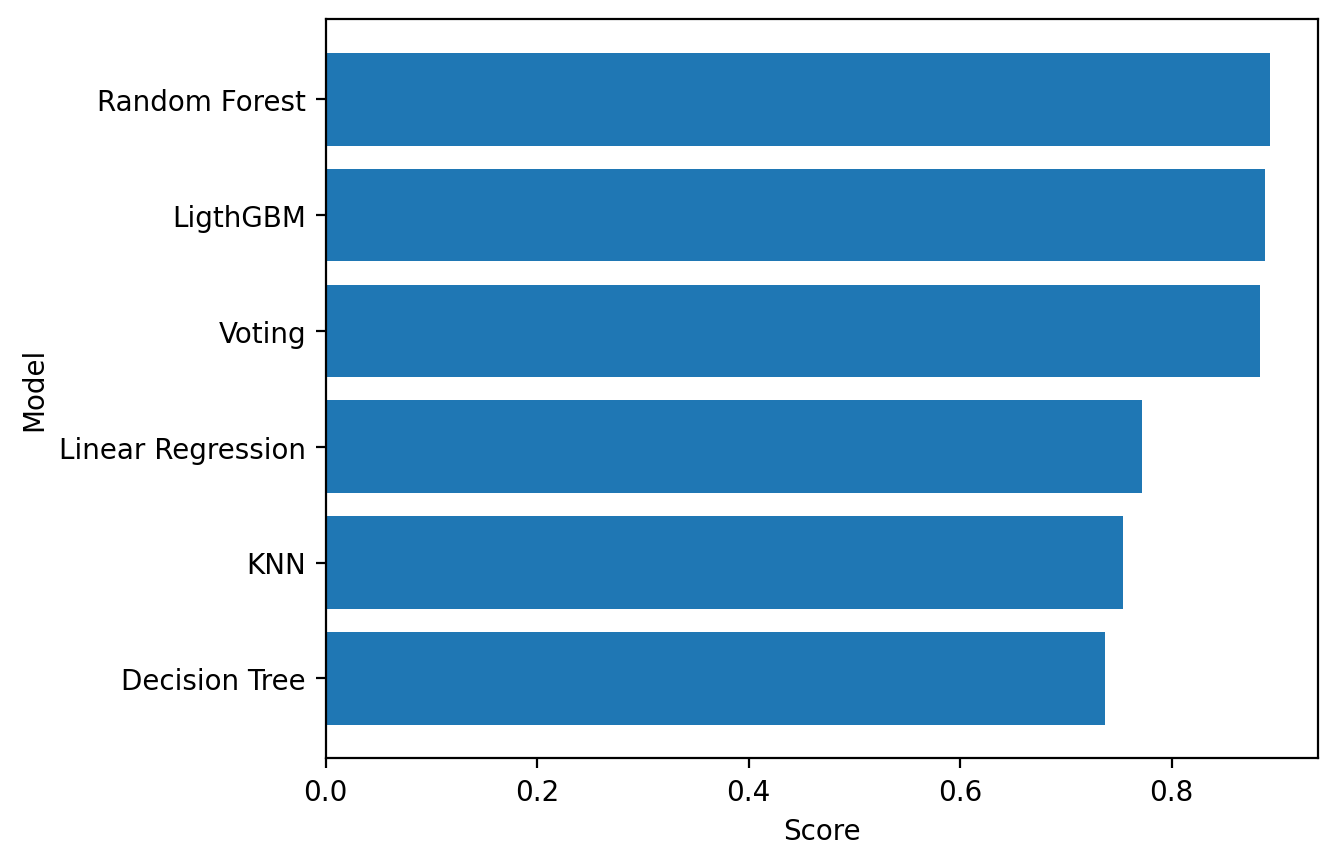

In [56]:
# 데이터 프레임 만들기
df_result = pd.DataFrame.from_dict(
  result,
  orient='index', # orient='index' : result의 키를 행으로 사용
  columns=['scores']
)

df_result.sort_values(by='scores', ascending=True, inplace=True)

plt.Figure(figsize=(8,5))
plt.barh(y=df_result.index,width=df_result['scores'])

plt.xlabel('Score')
plt.ylabel('Model')
plt.show()